# Scouting de jugadores subvalorados en LATAM
### Inteligencia de mercado para un fondo de inversión deportivo

**Curso:** AD3010 · Business Analytics · UTEC  
**Equipo:** Grupo 3 · Opción C (FIFA × Transfermarkt × World Bank)

---

## El encargo

Actuamos como una **consultora de datos** contratada por un fondo de inversión deportivo. El negocio del fondo es simple de enunciar y difícil de ejecutar: **comprar jugadores baratos respecto a lo que realmente valen, y capturar la diferencia cuando el mercado los corrige.** Es la lógica que clubes como Brentford o Brighton han convertido en un modelo rentable.

Nuestro trabajo no es invertir: es **entregarle al fondo la inteligencia de mercado** que le diga *dónde* están esas oportunidades en el fútbol joven de Latinoamérica, *por qué* existen, y *cómo* construir una cartera con ellas.

## La tesis

El mercado de fichajes no es perfectamente eficiente: el precio de un jugador no refleja solo su talento, sino también su fama, su liga y su país. Eso crea **jugadores subvalorados** — talento real que cotiza barato por razones ajenas a su calidad. Si podemos identificarlos con datos, el fondo tiene una ventaja.

## El enriquecimiento (el corazón del proyecto)

Cruzamos tres fuentes que por separado no responden nada, pero juntas sí:
- **FIFA 24** → la calidad del jugador (overall, potencial, habilidades).
- **Transfermarkt** → el precio real de mercado (y su historia).
- **World Bank** → el GDP per cápita del país (el contexto económico).

La pregunta que *no se puede responder sin este cruce*: **¿a igual talento, qué jugadores cotizan por debajo de lo que valen, y eso se corrige con el tiempo?**

## Cómo leer este notebook

Seguimos una sola historia, de afuera hacia adentro, en seis preguntas de negocio:

1. **¿Existe una ineficiencia que explotar?**
2. **¿Qué mueve el precio además del talento?**
3. **¿Cuánto vale realmente cada jugador?** (el motor)
4. **¿La subvaloración es sistemática o es azar?**
5. **¿Las gangas se aprecian con el tiempo?** (la prueba)
6. **¿Cómo se arma la cartera?**

Cada bloque tiene una celda de texto que plantea la pregunta, el código que la responde, y una lectura del hallazgo en lenguaje de cliente.

# Bloque 0 — Construcción de la base de datos

**Meta:** una tabla donde *1 fila = 1 jugador*, combinando calidad (FIFA), precio real (Transfermarkt) y contexto país (GDP).

**La decisión clave (Ruta B):** entrenamos los modelos con **todo el mundo** (para que aprendan cómo el mercado fija precios en general), pero **cazamos solo en LATAM joven** (donde está nuestro encargo). Por eso marcamos cada jugador con `is_latam` (¿dónde cazo?) y `is_matched` (¿tiene precio real, entra al modelo?), sin filtrar por país al construir la base.

El mayor reto técnico es el **cruce FIFA↔Transfermarkt**: no comparten un ID común, así que los unimos por una clave de nombre (inicial + apellido, sin tildes) y desempatamos por año de nacimiento y nacionalidad.

In [1]:
# Librerías
import pandas as pd
import numpy as np
import unicodedata, re
pd.set_option('display.max_columns', 60)
print('Librerías listas')

Librerías listas


## Carga de datos vía Kaggle API (sin Google Drive)

Este notebook **descarga los datasets automáticamente** desde Kaggle y el Banco Mundial: no necesitas Google Drive ni subir CSVs a mano. Ideal para clonar el repo y ejecutar de corrido.

**La primera vez, la celda te pedirá tu token de Kaggle como _input_** (lo escribes y ya):
1. Entra a <https://www.kaggle.com/settings> → sección **API** → **Create New Token**. Se descarga un `kaggle.json` que contiene tu **`username`** y tu **`key`**.
2. Corre la celda de abajo y, cuando aparezca el prompt, **escribe tu username y pega tu key**. El key se ingresa **oculto** y no queda guardado en el notebook.

> Alternativas opcionales (para no escribirlo cada vez): variables de entorno `KAGGLE_USERNAME` / `KAGGLE_KEY`, un `~/.kaggle/kaggle.json`, o *Secrets* (🔑) en Colab.
> El PIB del Banco Mundial (`NY.GDP.PCAP.CD`) se baja **sin token**.


In [ ]:
# === Carga de datos vía Kaggle API + Banco Mundial (sin Google Drive) ===
import subprocess, sys, os, glob, io, zipfile, urllib.request, getpass

# 1) Dependencia para descargar datasets de Kaggle
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "kagglehub"], check=False)

# 2) Credenciales de Kaggle — TE LAS PIDE COMO INPUT si no están ya configuradas.
#    Token: https://www.kaggle.com/settings -> API -> Create New Token (descarga kaggle.json).
def kaggle_login():
    # ¿Ya están disponibles? (no vuelve a preguntar)
    if os.environ.get("KAGGLE_USERNAME") and os.environ.get("KAGGLE_KEY"):
        return "variables de entorno"
    if os.path.exists(os.path.expanduser("~/.kaggle/kaggle.json")):
        return "~/.kaggle/kaggle.json"
    try:  # Colab Secrets (icono de llave), opcional
        from google.colab import userdata
        u, k = userdata.get("KAGGLE_USERNAME"), userdata.get("KAGGLE_KEY")
        if u and k:
            os.environ["KAGGLE_USERNAME"], os.environ["KAGGLE_KEY"] = u, k
            return "Colab Secrets"
    except Exception:
        pass

    # >>> Preguntar directamente (lo más simple) <<<
    print("🔑  Credenciales de Kaggle")
    print("    Token en https://www.kaggle.com/settings -> API -> Create New Token")
    print("    (abre el kaggle.json que se descarga: trae tu 'username' y tu 'key')\n")
    user = input("    Kaggle username: ").strip()
    key  = getpass.getpass("    Kaggle key (token — se ingresa oculto): ").strip()
    if not user or not key:
        raise ValueError("Username o key vacíos. Vuelve a correr la celda e ingrésalos.")
    os.environ["KAGGLE_USERNAME"] = user
    os.environ["KAGGLE_KEY"]      = key
    return "ingresado manualmente"

print("Autenticación Kaggle:", kaggle_login())
import kagglehub

# 3) Descargar (y cachear) los datasets de Kaggle
fifa_dir = kagglehub.dataset_download("stefanoleone992/ea-sports-fc-24-complete-player-dataset")
tm_dir   = kagglehub.dataset_download("davidcariboo/player-scores")

def _find(root, fname):
    hits = glob.glob(os.path.join(root, "**", fname), recursive=True)
    if not hits:
        raise FileNotFoundError(f"No encontré {fname} dentro de {root}")
    return hits[0]

FIFA_FILE  = _find(fifa_dir, "male_players.csv")
TM_PLAYERS = _find(tm_dir,   "players.csv")
TM_VALS    = _find(tm_dir,   "player_valuations.csv")   # histórico -> PA5

# 4) World Bank: PIB per cápita (descarga directa, sin token)
WB_URL = "https://api.worldbank.org/v2/en/indicator/NY.GDP.PCAP.CD?downloadformat=csv"
os.makedirs("worldbank_gdp", exist_ok=True)
_req = urllib.request.Request(WB_URL, headers={"User-Agent": "Mozilla/5.0"})
with urllib.request.urlopen(_req) as r:
    zipfile.ZipFile(io.BytesIO(r.read())).extractall("worldbank_gdp")
GDP_FILE = glob.glob("worldbank_gdp/API_NY.GDP.PCAP.CD_*.csv")[0]

print("\nArchivos listos:")
for _n in ("FIFA_FILE", "TM_PLAYERS", "TM_VALS", "GDP_FILE"):
    print(f"  {_n:11s} -> {os.path.basename(eval(_n))}")


In [3]:
# Cargar los datos crudos
df_fifa_raw = pd.read_csv(FIFA_FILE, low_memory=False)
df_tm_raw   = pd.read_csv(TM_PLAYERS, low_memory=False)
df_gdp_raw  = pd.read_csv(GDP_FILE, skiprows=4)   # el archivo del Banco Mundial trae 4 líneas de cabecera

print(f'FIFA (todas las versiones): {len(df_fifa_raw):>8,} filas')
print(f'Transfermarkt players:      {len(df_tm_raw):>8,} filas')
print(f'World Bank GDP:             {len(df_gdp_raw):>8,} países')

FIFA (todas las versiones):  180,021 filas
Transfermarkt players:        47,702 filas
World Bank GDP:                  266 países


In [4]:
# Países LATAM (universo de caza) y diccionario país → código ISO (para cruzar GDP del mundo)
LATAM = ['Argentina','Bolivia','Brazil','Chile','Colombia','Costa Rica',
         'Dominican Republic','Ecuador','El Salvador','Guatemala','Honduras',
         'Mexico','Nicaragua','Panama','Paraguay','Peru','Uruguay','Venezuela']

COUNTRY_ISO = {'Argentina':'ARG','Bolivia':'BOL','Brazil':'BRA','Chile':'CHL',
    'Colombia':'COL','Costa Rica':'CRI','Dominican Republic':'DOM','Ecuador':'ECU',
    'El Salvador':'SLV','Guatemala':'GTM','Honduras':'HND','Mexico':'MEX',
    'Nicaragua':'NIC','Panama':'PAN','Paraguay':'PRY','Peru':'PER',
    'Uruguay':'URY','Venezuela':'VEN','Spain':'ESP','France':'FRA','Germany':'DEU','Italy':'ITA',
    'England':'GBR','Scotland':'GBR','Wales':'GBR','Northern Ireland':'GBR',
    'Republic of Ireland':'IRL','Portugal':'PRT','Netherlands':'NLD','Belgium':'BEL',
    'Switzerland':'CHE','Austria':'AUT','Poland':'POL','Sweden':'SWE',
    'Norway':'NOR','Denmark':'DNK','Finland':'FIN','Iceland':'ISL',
    'Czech Republic':'CZE','Slovakia':'SVK','Hungary':'HUN','Romania':'ROU',
    'Bulgaria':'BGR','Croatia':'HRV','Serbia':'SRB','Slovenia':'SVN',
    'Bosnia and Herzegovina':'BIH','North Macedonia':'MKD','Montenegro':'MNE','Albania':'ALB',
    'Kosovo':'XKX','Greece':'GRC','Turkey':'TUR','Ukraine':'UKR','Russia':'RUS',
    'Belarus':'BLR','Lithuania':'LTU','Latvia':'LVA','Estonia':'EST',
    'Cyprus':'CYP','Malta':'MLT','Luxembourg':'LUX','Armenia':'ARM',
    'Georgia':'GEO','Azerbaijan':'AZE','Moldova':'MDA','Faroe Islands':'FRO',
    'Gibraltar':'GIB','Kazakhstan':'KAZ','Andorra':'AND','San Marino':'SMR','Liechtenstein':'LIE',
    'Morocco':'MAR','Algeria':'DZA','Tunisia':'TUN','Egypt':'EGY',
    'Senegal':'SEN','Ivory Coast':'CIV','Ghana':'GHA','Nigeria':'NGA',
    'Cameroon':'CMR','Mali':'MLI','Burkina Faso':'BFA','Guinea':'GIN',
    'DR Congo':'COD','Congo':'COG','Gabon':'GAB','Cape Verde Islands':'CPV',
    'South Africa':'ZAF','Angola':'AGO','Zambia':'ZMB','Zimbabwe':'ZWE',
    'Kenya':'KEN','Uganda':'UGA','Tanzania':'TZA','Mozambique':'MOZ',
    'Madagascar':'MDG','Equatorial Guinea':'GNQ','Togo':'TGO','Benin':'BEN',
    'Sierra Leone':'SLE','Liberia':'LBR','Gambia':'GMB','Guinea-Bissau':'GNB',
    'Mauritania':'MRT','Central African Republic':'CAF','Chad':'TCD','Niger':'NER',
    'Sudan':'SDN','Comoros':'COM','Libya':'LBY','Burundi':'BDI',
    'Rwanda':'RWA','Namibia':'NAM','Botswana':'BWA','Ethiopia':'ETH',
    'South Sudan':'SSD','Lesotho':'LSO','Eswatini':'SWZ','Malawi':'MWI',
    'Seychelles':'SYC','Mauritius':'MUS',
    'Japan':'JPN','Korea Republic':'KOR','Korea DPR':'PRK','China PR':'CHN',
    'Australia':'AUS','New Zealand':'NZL','Iran':'IRN','Iraq':'IRQ',
    'Saudi Arabia':'SAU','Qatar':'QAT','United Arab Emirates':'ARE','Syria':'SYR',
    'Lebanon':'LBN','Jordan':'JOR','Palestine':'PSE','Uzbekistan':'UZB',
    'India':'IND','Thailand':'THA','Vietnam':'VNM','Philippines':'PHL',
    'Indonesia':'IDN','Malaysia':'MYS','Singapore':'SGP','Hong Kong':'HKG',
    'Oman':'OMN','Kuwait':'KWT','Bahrain':'BHR','Yemen':'YEM',
    'Tajikistan':'TJK','Turkmenistan':'TKM','Kyrgyzstan':'KGZ','Afghanistan':'AFG',
    'Chinese Taipei':'TWN','Fiji':'FJI','Papua New Guinea':'PNG','New Caledonia':'NCL',
    'Tahiti':'PYF','Solomon Islands':'SLB','Vanuatu':'VUT',
    'United States':'USA','Canada':'CAN','Jamaica':'JAM','Trinidad and Tobago':'TTO',
    'Haiti':'HTI','Cuba':'CUB','Suriname':'SUR','Curacao':'CUW',
    'Antigua and Barbuda':'ATG','Grenada':'GRD','Barbados':'BRB','Saint Kitts and Nevis':'KNA',
    'Saint Lucia':'LCA','Saint Vincent and the Grenadines':'VCT','Dominica':'DMA','Bahamas':'BHS',
    'Bermuda':'BMU','Guyana':'GUY','Belize':'BLZ','Puerto Rico':'PRI',
    'Aruba':'ABW','Montserrat':'MSR','Cayman Islands':'CYM','US Virgin Islands':'VIR',
    'British Virgin Islands':'VGB','Turks and Caicos Islands':'TCA'}
print(f'{len(LATAM)} países LATAM | {len(COUNTRY_ISO)} países mapeados a ISO')

18 países LATAM | 187 países mapeados a ISO


In [5]:
# Filtrar FIFA 24, jugadores de campo, e imputar/derivar variables de CALIDAD
fifa = df_fifa_raw[df_fifa_raw['fifa_version'].astype(float) == 24.0].copy()
fifa = fifa[fifa['player_positions'] != 'GK'].copy()          # sin arqueros (otra lógica de valor)

# Imputar nulos de las 6 habilidades con la MEDIANA de su posición
SKILLS = ['pace','shooting','passing','dribbling','defending','physic']
for c in SKILLS:
    fifa[c] = fifa.groupby('player_positions')[c].transform(lambda x: x.fillna(x.median()))

# Sin valor FIFA no hay análisis → fuera
fifa = fifa.dropna(subset=['value_eur'])
fifa = fifa[fifa['value_eur'] > 0]

# Variables derivadas de calidad
fifa['pos_main']    = fifa['player_positions'].str.split(',').str[0].str.strip()
fifa['skill_index'] = fifa[SKILLS].mean(axis=1)
fifa['growth_room'] = fifa['potential'] - fifa['overall']     # techo: cuánto puede mejorar

POS_GROUP = {'ST':'Delantero','CF':'Delantero','LW':'Delantero','RW':'Delantero',
    'CAM':'Mediocampista','CM':'Mediocampista','CDM':'Mediocampista','LM':'Mediocampista','RM':'Mediocampista',
    'LB':'Defensa','RB':'Defensa','CB':'Defensa','LWB':'Defensa','RWB':'Defensa'}
fifa['pos_group'] = fifa['pos_main'].map(POS_GROUP)

# Año de nacimiento (para desambiguar el cruce con Transfermarkt)
fifa['fifa_byear'] = pd.to_datetime(fifa['dob'], errors='coerce').dt.year
fifa['fifa_byear'] = fifa['fifa_byear'].fillna(2023 - fifa['age'])

# 🌎 La marca clave de la Ruta B: ¿es LATAM? (define DÓNDE cazamos, no con qué entrenamos)
fifa['is_latam'] = fifa['nationality_name'].isin(LATAM)
print(f'Jugadores de campo en FIFA 24 (MUNDO): {len(fifa):,}')
print(f'   de los cuales LATAM:                {fifa["is_latam"].sum():,}')

Jugadores de campo en FIFA 24 (MUNDO): 16,217
   de los cuales LATAM:                2,982


In [6]:
# Construir la clave de cruce: inicial del nombre + apellido, sin tildes
def _strip(s):
    s = str(s).lower().strip()
    s = unicodedata.normalize('NFKD', s).encode('ascii','ignore').decode('ascii')
    s = re.sub(r'[^a-z ]', ' ', s)
    return re.sub(r'\s+', ' ', s).strip()

def make_key(name):
    if pd.isna(name): return None
    t = _strip(name).split()
    if not t: return None
    return t[0] if len(t) == 1 else t[0][0] + ' ' + t[-1]   # ej. 'Lionel Andrés Messi' -> 'l messi'

# Transfermarkt: todo el mundo, con clave de nombre y nacionalidad
tm = df_tm_raw.copy()
tm['tm_byear']  = pd.to_datetime(tm['date_of_birth'], errors='coerce').dt.year
tm['name_key']  = tm['name'].apply(make_key)
tm['nat_key']   = tm['country_of_citizenship'].apply(_strip)

fifa['name_key'] = fifa['long_name'].apply(make_key)
fifa['nat_key']  = fifa['nationality_name'].apply(_strip)
print('Claves de nombre y nacionalidad construidas (mundo completo).')

Claves de nombre y nacionalidad construidas (mundo completo).


In [7]:
# Cruzar FIFA con Transfermarkt: por nombre, desempatando por año de nacimiento y nacionalidad
tm_cols = tm[['name_key','nat_key','tm_byear','market_value_in_eur','highest_market_value_in_eur',
              'international_caps','sub_position']].rename(columns={
    'market_value_in_eur':'tm_value_eur',
    'highest_market_value_in_eur':'tm_peak_value_eur',
    'sub_position':'tm_sub_position'})
cand = fifa.merge(tm_cols, on='name_key', how='left', suffixes=('','_tm'))

cand['byear_diff'] = (cand['fifa_byear'] - cand['tm_byear']).abs()
cand['nat_match']  = (cand['nat_key'] == cand['nat_key_tm']).astype(int)

# Mejor candidato por jugador: menor diferencia de edad; si empatan, misma nacionalidad
df = (cand.sort_values(['byear_diff','nat_match'], ascending=[True, False])
          .drop_duplicates('player_id', keep='first'))

# Aceptar el match solo si nacieron con <=1 año de diferencia (evita homónimos)
not_same = df['byear_diff'] > 1
df.loc[not_same, ['tm_value_eur','tm_peak_value_eur','tm_sub_position','international_caps']] = np.nan

m_world = df['tm_value_eur'].notna().sum()
m_latam = df.loc[df['is_latam'], 'tm_value_eur'].notna().sum()
print(f'Match con Transfermarkt (MUNDO):  {m_world:,} de {len(df):,}  ({m_world/len(df)*100:.1f}%)')
print(f'Match con Transfermarkt (LATAM):  {m_latam:,} de {df["is_latam"].sum():,}')

Match con Transfermarkt (MUNDO):  8,569 de 16,217  (52.8%)
Match con Transfermarkt (LATAM):  833 de 2,982


In [8]:
# Agregar GDP per cápita del país y armar la tabla analítica final 'base'
gdp = df_gdp_raw[['Country Code','2023']].rename(columns={'2023':'gdp_per_capita_2023'})
df['country_iso'] = df['nationality_name'].map(COUNTRY_ISO)
df = df.merge(gdp, left_on='country_iso', right_on='Country Code', how='left').drop(columns='Country Code')

df['is_matched'] = df['tm_value_eur'].notna()      # ¿tiene precio real? → entra al modelo

COLS = ['player_id','short_name','long_name','nationality_name','is_latam','country_iso',
        'club_name','league_name','age','fifa_byear','pos_main','pos_group',
        'overall','potential','growth_room','skill_index',
        'pace','shooting','passing','dribbling','defending','physic',
        'value_eur','tm_value_eur','tm_peak_value_eur','tm_sub_position',
        'international_caps','gdp_per_capita_2023','is_matched']
base = df[[c for c in COLS if c in df.columns]].copy()

print('Tabla base —', base.shape)
display(base.head(8))
print('\n=== REPORTE DE CALIDAD ===')
print(f"Jugadores de campo (mundo):       {len(base):,}")
print(f"  → LATAM (universo de caza):     {base['is_latam'].sum():,}")
print(f"Con precio real (entrenamiento):  {base['is_matched'].sum():,}  ({base['is_matched'].mean()*100:.1f}%)")
print(f"  → LATAM con precio real:        {base[base['is_latam']]['is_matched'].sum():,}")
print(f"Con GDP del país:                 {base['gdp_per_capita_2023'].notna().sum():,}")

Tabla base — (16217, 29)


,player_id,short_name,long_name,nationality_name,is_latam,country_iso,club_name,league_name,age,fifa_byear,pos_main,pos_group,overall,potential,growth_room,skill_index,pace,shooting,passing,dribbling,defending,physic,value_eur,tm_value_eur,tm_peak_value_eur,tm_sub_position,international_caps,gdp_per_capita_2023,is_matched
0,239085,E. Haaland,Erling Braut Haaland,Norway,False,NOR,Manchester City,Premier League,22,2000,ST,Delantero,91,94,3,76.833333,89.0,93.0,66.0,80.0,45.0,88.0,185000000.0,200000000.0,200000000.0,Centre-Forward,48.0,87497.217965,True
1,192985,K. De Bruyne,Kevin De Bruyne,Belgium,False,BEL,Manchester City,Premier League,32,1991,CM,Mediocampista,91,91,0,80.666667,72.0,88.0,94.0,87.0,65.0,78.0,103000000.0,10000000.0,150000000.0,Attacking Midfield,115.0,55291.475454,True
2,165153,K. Benzema,Karim Benzema,France,False,FRA,Al Ittihad,Pro League,35,1987,CF,Delantero,90,90,0,75.666667,79.0,88.0,83.0,87.0,39.0,78.0,51000000.0,6000000.0,60000000.0,Centre-Forward,97.0,44700.138418,True
3,188545,R. Lewandowski,Robert Lewandowski,Poland,False,POL,FC Barcelona,La Liga,34,1988,ST,Delantero,90,90,0,76.833333,75.0,91.0,80.0,87.0,44.0,84.0,58000000.0,8000000.0,90000000.0,Centre-Forward,164.0,22145.266065,True
4,202126,H. Kane,Harry Kane,England,False,GBR,FC Bayern München,Bundesliga,29,1993,ST,Delantero,90,90,0,76.833333,69.0,93.0,84.0,83.0,49.0,83.0,119500000.0,65000000.0,150000000.0,Centre-Forward,112.0,49944.470212,True
5,238794,Vini Jr.,Vinícius José Paixão de Oliveira Júnior,Brazil,True,BRA,Real Madrid,La Liga,22,2000,LW,Delantero,89,94,5,73.666667,95.0,82.0,78.0,90.0,29.0,68.0,158500000.0,150000000.0,200000000.0,Left Winger,46.0,10377.589772,True
6,239818,Rúben Dias,Rúben dos Santos Gato Alves Dias,Portugal,False,PRT,Manchester City,Premier League,26,1997,CB,Defensa,89,90,1,68.666667,62.0,39.0,66.0,69.0,89.0,87.0,106500000.0,60000000.0,80000000.0,Centre-Back,74.0,27634.618314,True
7,203376,V. van Dijk,Virgil van Dijk,Netherlands,False,NLD,Liverpool,Premier League,31,1991,CB,Defensa,89,89,0,76.000000,78.0,60.0,71.0,72.0,89.0,86.0,70500000.0,18000000.0,100000000.0,Centre-Back,88.0,63515.603078,True



=== REPORTE DE CALIDAD ===
Jugadores de campo (mundo):       16,217
  → LATAM (universo de caza):     2,982
Con precio real (entrenamiento):  8,569  (52.8%)
  → LATAM con precio real:        833
Con GDP del país:                 15,992


**Lectura del bloque.** Quedamos con ~16,000 jugadores de campo del mundo, ~3,000 de ellos LATAM, y poco más de la mitad con precio real de Transfermarkt (los que alimentan los modelos). El cruce por nombre+año recupera bastante más que un cruce ingenuo, a costa de perder algunos apodos (ej. "Pedri"), un precio razonable de pagar. Con esta tabla `base` —calidad + precio + contexto en una sola fila por jugador— ya podemos empezar a preguntar.

# PA1 — ¿Existe una ineficiencia que explotar?

**La pregunta de negocio.** Antes de buscar gangas, hay que probar que las gangas *pueden* existir. Si el mercado fuera perfectamente eficiente, el precio de un jugador estaría determinado casi por completo por su talento, y no habría margen para comprar barato. Así que medimos: **¿cuánto del precio explica el talento?** Si la respuesta es "no todo", el espacio que sobra es nuestra oportunidad.

Correlación calidad ↔ precio:  r = 0.493  |  R² = 0.243
La calidad explica el 24% del precio.
El 76% restante NO lo explica el talento por sí solo → ahí hay margen.


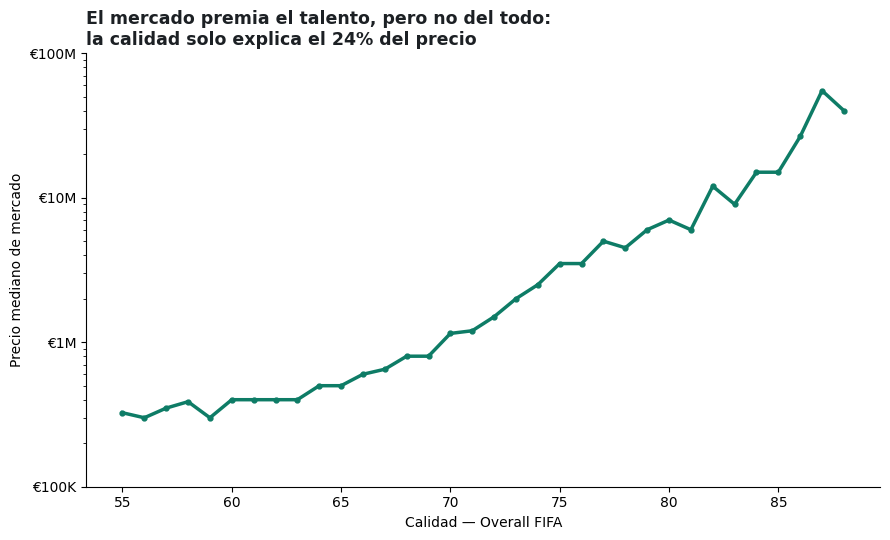

In [9]:
# PA1 — ¿La calidad explica el precio?
import numpy as np
import matplotlib.pyplot as plt
INK, HL = '#1C2024', '#0E7C66'

# Solo jugadores con precio real de mercado
m = base[base['is_matched'] & (base['tm_value_eur'] > 0)].copy()

# El precio crece exponencialmente con la calidad → usamos log10 para medir la relación de forma justa
m['log_value'] = np.log10(m['tm_value_eur'])

# La evidencia en números
r  = m['overall'].corr(m['log_value'])
r2 = r**2
print(f'Correlación calidad ↔ precio:  r = {r:.3f}  |  R² = {r2:.3f}')
print(f'La calidad explica el {r2*100:.0f}% del precio.')
print(f'El {100-r2*100:.0f}% restante NO lo explica el talento por sí solo → ahí hay margen.')

# La evidencia visual: precio MEDIANO por nivel de calidad
g = m.groupby('overall')['tm_value_eur'].median()
g = g[(g.index >= 55) & (g.index <= 88)]
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(g.index, g.values, color=HL, lw=2.5, marker='o', ms=3.5)
ax.set_yscale('log')
ax.set_yticks([1e5, 1e6, 1e7, 1e8]); ax.set_yticklabels(['€100K', '€1M', '€10M', '€100M'])
ax.set_title('El mercado premia el talento, pero no del todo:\n'
             f'la calidad solo explica el {r2*100:.0f}% del precio',
             fontsize=12.5, fontweight='bold', color=INK, loc='left')
ax.set_xlabel('Calidad — Overall FIFA'); ax.set_ylabel('Precio mediano de mercado')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout(); plt.show()

**Hallazgo (en lenguaje de cliente).** El talento explica solo **alrededor de una cuarta parte** del precio de un jugador. Las tres cuartas partes restantes responden a *otras cosas* — fama, liga, país, momento. **Ese hueco es el negocio del fondo:** si el precio no sigue al talento de forma perfecta, hay jugadores buenos que cotizan barato. La ineficiencia existe; ahora hay que entenderla.

# PA2 — ¿Qué mueve el precio además del talento?

**La pregunta de negocio.** Si el talento no basta para explicar el precio, ¿qué más pesa? Conocer esas "reglas del mercado" es lo que después nos permite construir un modelo de *precio justo*. Exploramos una variable a la vez para ver cómo cada una empuja el precio.

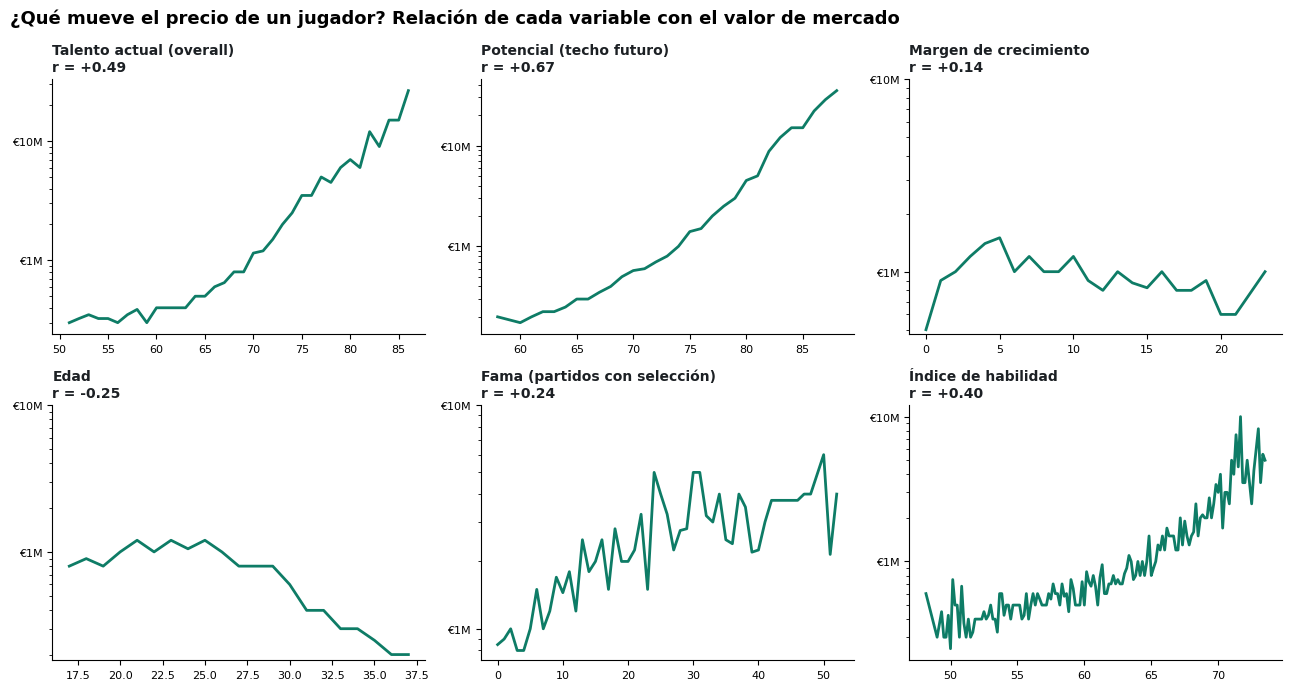

In [10]:
# PA2 — ¿Cómo se relaciona cada variable con el precio? (precio mediano por nivel)
import numpy as np
import matplotlib.pyplot as plt
HL, INK = '#0E7C66', '#1C2024'

m = base[base['is_matched'] & (base['tm_value_eur'] > 0)].copy()
m['log_value'] = np.log10(m['tm_value_eur'])

variables = [('overall',            'Talento actual (overall)'),
             ('potential',          'Potencial (techo futuro)'),
             ('growth_room',        'Margen de crecimiento'),
             ('age',                'Edad'),
             ('international_caps',  'Fama (partidos con selección)'),
             ('skill_index',        'Índice de habilidad')]

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for ax, (col, label) in zip(axes.ravel(), variables):
    g   = m.groupby(col)['tm_value_eur'].median()
    cnt = m.groupby(col).size()
    g   = g[cnt >= 15]                          # ignora niveles con muy pocos jugadores
    ax.plot(g.index, g.values, color=HL, lw=2)
    r = m[col].corr(m['log_value'])
    ax.set_title(f'{label}\nr = {r:+.2f}', fontsize=10, fontweight='bold', color=INK, loc='left')
    ax.set_yscale('log')
    ax.set_yticks([1e6, 1e7]); ax.set_yticklabels(['€1M', '€10M'], fontsize=8)
    ax.tick_params(labelsize=8)
    ax.spines[['top', 'right']].set_visible(False)
fig.suptitle('¿Qué mueve el precio de un jugador? Relación de cada variable con el valor de mercado',
             fontsize=13, fontweight='bold', x=0.01, ha='left')
plt.tight_layout(); plt.show()

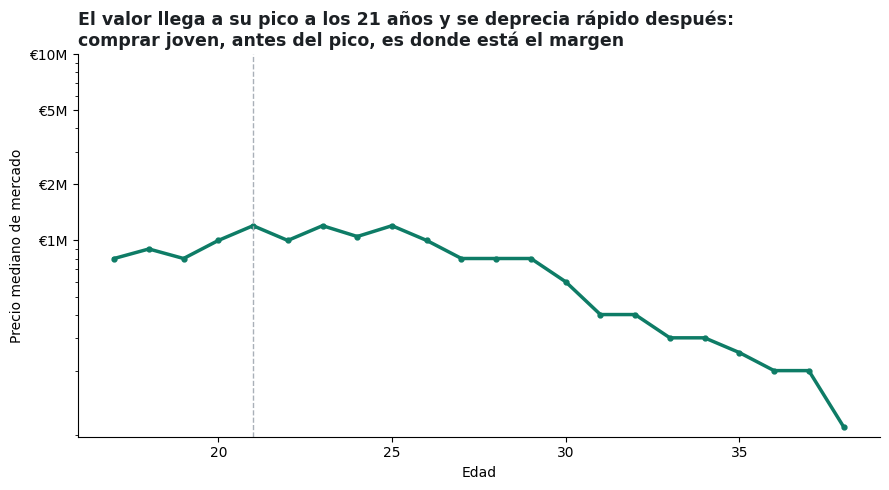

In [11]:
# PA2 — El efecto de la edad (no es lineal: sube, hace pico y cae)
ag = m.groupby('age')['tm_value_eur'].median()
ag = ag[(ag.index >= 17) & (ag.index <= 38)]
peak = int(ag.idxmax())

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(ag.index, ag.values, color=HL, lw=2.5, marker='o', ms=3.5)
ax.axvline(peak, color='#A9B0B8', ls='--', lw=1)
ax.set_yscale('log')
ax.set_yticks([1e6, 2e6, 5e6, 1e7]); ax.set_yticklabels(['€1M', '€2M', '€5M', '€10M'])
ax.set_title(f'El valor llega a su pico a los {peak} años y se deprecia rápido después:\n'
             f'comprar joven, antes del pico, es donde está el margen',
             fontsize=12.5, fontweight='bold', color=INK, loc='left')
ax.set_xlabel('Edad'); ax.set_ylabel('Precio mediano de mercado')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout(); plt.show()

### Un detalle que hay que desenredar: el margen de crecimiento

Arriba, el "margen de crecimiento" (cuánto puede mejorar un jugador) salió **casi plano** — pareciera que el mercado no lo paga. Pero sospechamos que es un espejismo: el margen está **confundido** con la edad y el talento (los jóvenes tienen más margen, pero también menos overall). Antes de modelar, lo desenredamos a mano para no sacar la conclusión equivocada.

In [12]:
# Exploración: perfil del jugador según su margen de crecimiento (¿con qué se confunde?)
m = base[base['is_matched'] & (base['tm_value_eur'] > 0)].copy()
m['gr_band'] = pd.cut(m['growth_room'], [-1, 1, 4, 7, 99], labels=['0-1', '2-4', '5-7', '8+'])

tabla = m.groupby('gr_band', observed=True).agg(
    overall_medio = ('overall', 'mean'),
    edad_media    = ('age', 'mean'),
    precio_mediano= ('tm_value_eur', 'median'),
    n             = ('player_id', 'size')).round(1)
print('Perfil del jugador según su margen de crecimiento:')
print(tabla)

Perfil del jugador según su margen de crecimiento:
         overall_medio  edad_media  precio_mediano     n
gr_band                                                 
0-1               70.2        29.8        500000.0  3184
2-4               69.6        25.2       1200000.0  1216
5-7               68.0        23.3       1200000.0  1419
8+                63.2        20.3       1000000.0  2750


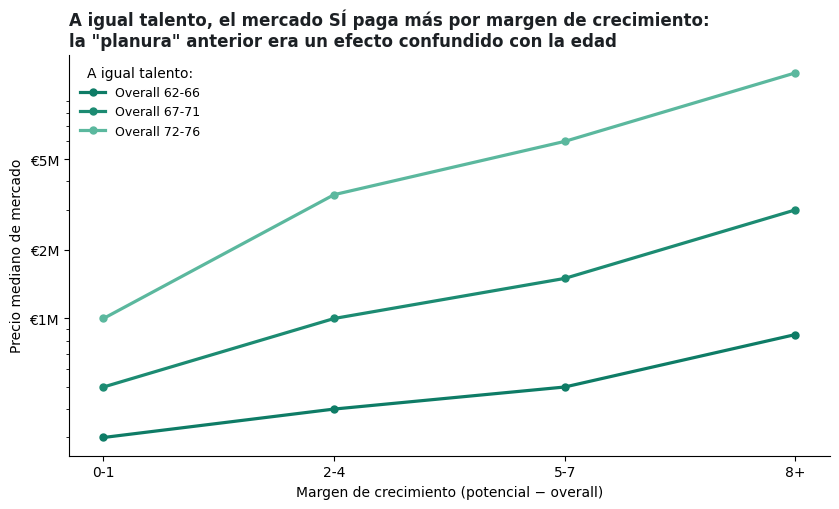

In [13]:
# Exploración: A IGUAL TALENTO, ¿el margen sí paga? (fijamos overall y comparamos)
import matplotlib.pyplot as plt
COLORS = ['#0E7C66', '#1C8B72', '#5BB89E']; INK = '#1C2024'
bands  = [(62, 66, '62-66'), (67, 71, '67-71'), (72, 76, '72-76')]

fig, ax = plt.subplots(figsize=(8.5, 5.2))
for (lo, hi, lab), c in zip(bands, COLORS):
    sub = m[m['overall'].between(lo, hi)]                       # fijamos el talento
    g   = sub.groupby('gr_band', observed=True)['tm_value_eur'].median()
    ax.plot(range(len(g)), g.values, color=c, lw=2.3, marker='o', ms=5, label=f'Overall {lab}')

ax.set_xticks(range(4)); ax.set_xticklabels(['0-1', '2-4', '5-7', '8+'])
ax.set_yscale('log'); ax.set_yticks([1e6, 2e6, 5e6]); ax.set_yticklabels(['€1M', '€2M', '€5M'])
ax.legend(frameon=False, fontsize=9, title='A igual talento:')
ax.set_title('A igual talento, el mercado SÍ paga más por margen de crecimiento:\n'
             'la "planura" anterior era un efecto confundido con la edad',
             fontsize=12, fontweight='bold', color=INK, loc='left')
ax.set_xlabel('Margen de crecimiento (potencial − overall)')
ax.set_ylabel('Precio mediano de mercado')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout(); plt.show()

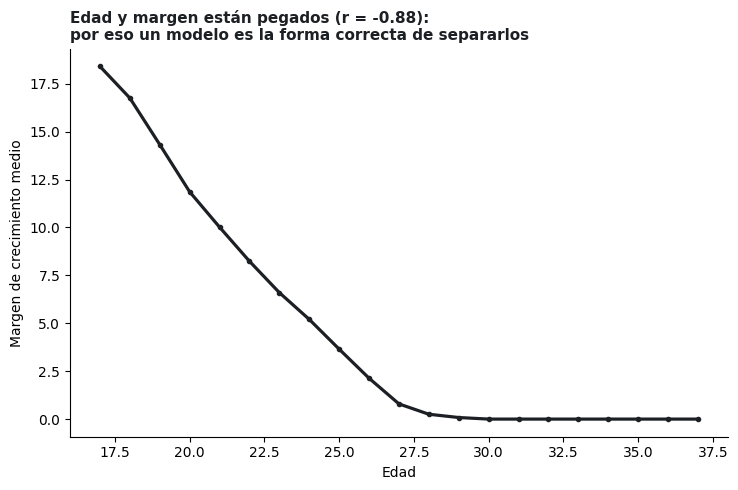

In [14]:
# Exploración: por qué no se podía separar a mano — edad y margen están pegados
import matplotlib.pyplot as plt
INK, HL = '#1C2024', '#0E7C66'

g = m.groupby('age')['growth_room'].mean()
g = g[(g.index >= 17) & (g.index <= 37)]
fig, ax = plt.subplots(figsize=(7.5, 5))
ax.plot(g.index, g.values, color=INK, lw=2.3, marker='o', ms=3)
r = m['age'].corr(m['growth_room'])
ax.set_title(f'Edad y margen están pegados (r = {r:+.2f}):\npor eso un modelo es la forma correcta de separarlos',
             fontsize=11, fontweight='bold', color=INK, loc='left')
ax.set_xlabel('Edad'); ax.set_ylabel('Margen de crecimiento medio')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout(); plt.show()

**Hallazgo (en lenguaje de cliente).** El precio lo mueven, en orden: el **talento** (overall), el **potencial/margen de crecimiento**, la **edad** (con un pico claro ~24 años y caída rápida después) y la **fama**. El aprendizaje clave: el mercado *sí* premia el margen de crecimiento, pero ese efecto estaba escondido porter la edad. Como varias variables se entrelazan, separarlas "a mano" no alcanza — **necesitamos un modelo** que controle todo a la vez. Eso es PA3.

# Bloque intermedio — ¿Dónde cazamos?

Antes de modelar, acotamos el **universo de caza**: a qué jugadores vale la pena mirar. Esto NO es decidir quién es ganga (eso lo hace el modelo); es decidir *dónde buscar*. Aplicamos tres filtros — LATAM, con precio real, y jóvenes — y vemos cuántos quedan en cada paso. La regla mental: **filtrar = dónde cazar; el modelo = a cuál disparar.**

EMBUDO DE CANDIDATOS:
  Mundo (todos)         : 16,217
  LATAM                 :  2,982
  LATAM con precio      :    833
  + jóvenes (≤23)       :    303


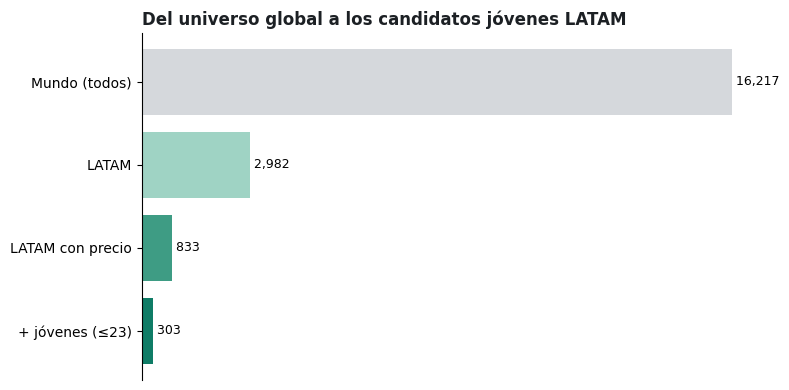

In [15]:
# Embudo: del universo global a los candidatos jóvenes LATAM
f0 = base
f1 = f0[f0['is_latam']]                                       # solo LATAM
f2 = f1[f1['is_matched'] & (f1['tm_value_eur'] > 0)]          # con precio real
f3 = f2[f2['age'] <= 23]                                      # jóvenes (antes del pico)

pasos = [('Mundo (todos)', f0), ('LATAM', f1), ('LATAM con precio', f2), ('+ jóvenes (≤23)', f3)]
print('EMBUDO DE CANDIDATOS:')
for lab, f in pasos:
    print(f'  {lab:22s}: {len(f):>6,}')

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(8, 4))
labs = [p[0] for p in pasos]; vals = [len(p[1]) for p in pasos]
ax.barh(range(len(labs)), vals, color=['#D5D8DC', '#9FD3C4', '#3E9C84', '#0E7C66'])
ax.set_yticks(range(len(labs))); ax.set_yticklabels(labs); ax.invert_yaxis()
for i, v in enumerate(vals): ax.text(v, i, f' {v:,}', va='center', fontsize=9)
ax.set_title('Del universo global a los candidatos jóvenes LATAM',
             fontsize=12, fontweight='bold', color='#1C2024', loc='left')
ax.spines[['top', 'right', 'bottom']].set_visible(False); ax.set_xticks([])
plt.tight_layout(); plt.show()

In [16]:
# Elegir el corte de edad con los números delante (no a dedo)
lat = base[base['is_latam'] & base['is_matched'] & (base['tm_value_eur'] > 0)]
print('Candidatos LATAM según el corte de edad:')
for cut in [20, 21, 22, 23, 24, 25]:
    s = lat[lat['age'] <= cut]
    print(f'  ≤ {cut} años: {len(s):>4} candidatos | margen de crecimiento medio: {s["growth_room"].mean():.1f}')

Candidatos LATAM según el corte de edad:
  ≤ 20 años:  116 candidatos | margen de crecimiento medio: 12.7
  ≤ 21 años:  172 candidatos | margen de crecimiento medio: 11.9
  ≤ 22 años:  235 candidatos | margen de crecimiento medio: 10.9
  ≤ 23 años:  303 candidatos | margen de crecimiento medio: 9.9
  ≤ 24 años:  370 candidatos | margen de crecimiento medio: 9.1
  ≤ 25 años:  435 candidatos | margen de crecimiento medio: 8.3


In [17]:
# Fijar el corte y perfilar el universo de caza
EDAD_MAX = 23   # decisión de negocio: el valor pica ~24-25 y el margen se agota ~27 → ≤23 deja recorrido

candidatos = base[base['is_latam'] & base['is_matched'] &
                  (base['tm_value_eur'] > 0) & (base['age'] <= EDAD_MAX)].copy()
print(f'UNIVERSO DE CAZA: {len(candidatos)} jóvenes LATAM con precio\n')
print('Por posición:')
print(candidatos['pos_group'].value_counts())
print('\nRango de precios (€):')
print(candidatos['tm_value_eur'].describe()[['min','25%','50%','75%','max']].apply(lambda v: f'€{v/1e6:.2f}M'))

UNIVERSO DE CAZA: 303 jóvenes LATAM con precio

Por posición:
pos_group
Mediocampista    151
Defensa           93
Delantero         59
Name: count, dtype: int64

Rango de precios (€):
min      €0.01M
25%      €0.40M
50%      €1.50M
75%      €4.00M
max    €150.00M
Name: tm_value_eur, dtype: object


**Lectura.** De ~16,000 jugadores en el mundo nos concentramos en unos cientos de jóvenes LATAM con precio. El corte en ≤23 años no es arbitrario: equilibra cantidad (suficientes para diversificar) con margen (techo todavía amplio, antes del pico de valor). Sobre este grupo el modelo dirá, ahora sí, cuáles están subvalorados.

# PA3 — ¿Cuánto vale realmente cada jugador? (el motor)

**La pregunta de negocio.** Este es el corazón del proyecto. Construimos un modelo que estima el **precio justo** de cada jugador a partir *solo* de su talento, edad y posición. La diferencia entre lo que **cuesta** y lo que **vale** es la señal: si cuesta menos que su valor justo, está **subvalorado** (comprar); si cuesta más, **sobrevalorado** (evitar).

**La decisión clave:** el modelo usa *solo* talento, edad y posición — **deja afuera a propósito** la fama, la liga y el país. ¿Por qué? Porque queremos que *esos* factores aparezcan como **desviación** (la oportunidad), no como parte del "precio correcto". Si metiéramos la fama, el modelo justificaría que un jugador mediático sea caro, y dejaríamos de verlo como subvalorado.

Lo hacemos en cuatro pasos: (1) construir el modelo, (2) mirar la distribución del error, (3) definir el umbral de "subvalorado", (4) graficar la brecha.

In [18]:
# PA3.1 — Construir y evaluar el modelo de precio justo
import numpy as np, pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# Entrenamos con TODO el mundo que tiene precio (necesita ver todas las edades para aprender la depreciación)
t = base[base['is_matched'] & (base['tm_value_eur'] > 0) & base['pos_group'].notna()].copy()
t['log_value'] = np.log10(t['tm_value_eur'])     # precio en log (es exponencial)
t['age_sq']    = t['age']**2                     # término curvo (el valor sube y luego cae)

# Predictores = SOLO talento, edad y posición (sin fama/liga/país, a propósito)
Xnum = ['overall', 'growth_room', 'age', 'age_sq']
X = pd.concat([t[Xnum], pd.get_dummies(t['pos_group'], prefix='pos', drop_first=True)], axis=1).astype(float)
y = t['log_value']

# Limpieza: un primer ajuste detecta matches imposibles (outliers a >3σ del modelo)
resid0 = y - LinearRegression().fit(X, y).predict(X)
clean  = resid0.abs() <= 3*resid0.std()
print(f'Matches implausibles removidos: {(~clean).sum()} de {len(t)}')
Xc, yc = X[clean], y[clean]

# Train/test para medir si GENERALIZA
Xtr, Xte, ytr, yte = train_test_split(Xc, yc, test_size=0.25, random_state=42)
r2 = r2_score(yte, LinearRegression().fit(Xtr, ytr).predict(Xte))
print(f'R² en test = {r2:.3f}   (con solo overall daba 0.24 → el modelo completo explica mucho más)')

# Modelo final + lectura para el cliente
model = LinearRegression().fit(Xc, yc)
print('\n¿Cuánto suma cada factor al precio, a igualdad del resto?')
for c, b in zip(X.columns, model.coef_):
    if c in ('age', 'age_sq'): continue
    print(f'  {c:18s}: {(10**b - 1)*100:+.0f}% de precio por unidad')
print('  edad               : efecto en curva (pico y caída)')

# Guardar el precio justo de cada jugador en la base
base = base.drop(columns=[c for c in ['fair_value_eur'] if c in base.columns])
t['fair_value_eur'] = 10**model.predict(X)
base = base.merge(t[['player_id', 'fair_value_eur']], on='player_id', how='left')
print('\nPrecio justo calculado y guardado en base.')

Matches implausibles removidos: 106 de 8569
R² en test = 0.573   (con solo overall daba 0.24 → el modelo completo explica mucho más)

¿Cuánto suma cada factor al precio, a igualdad del resto?
  overall           : +22% de precio por unidad
  growth_room       : +4% de precio por unidad
  pos_Delantero     : +8% de precio por unidad
  pos_Mediocampista : +2% de precio por unidad
  edad               : efecto en curva (pico y caída)

Precio justo calculado y guardado en base.


**Lectura del modelo.** El R² de test sube de 0.24 (solo talento) a ~0.57: juntar talento, edad, margen y posición explica **más de la mitad** del precio, y como es *test*, no está memorizando. Cada coeficiente se lee en plata: cada punto de overall vale ~+22%, cada punto de margen ~+4%, los delanteros ~+8% más. Pero ojo: queda un ~43% **sin explicar** — y ahí, en ese residuo, viven los subvalorados. El modelo no es perfecto a propósito: si lo fuera, no habría oportunidad.

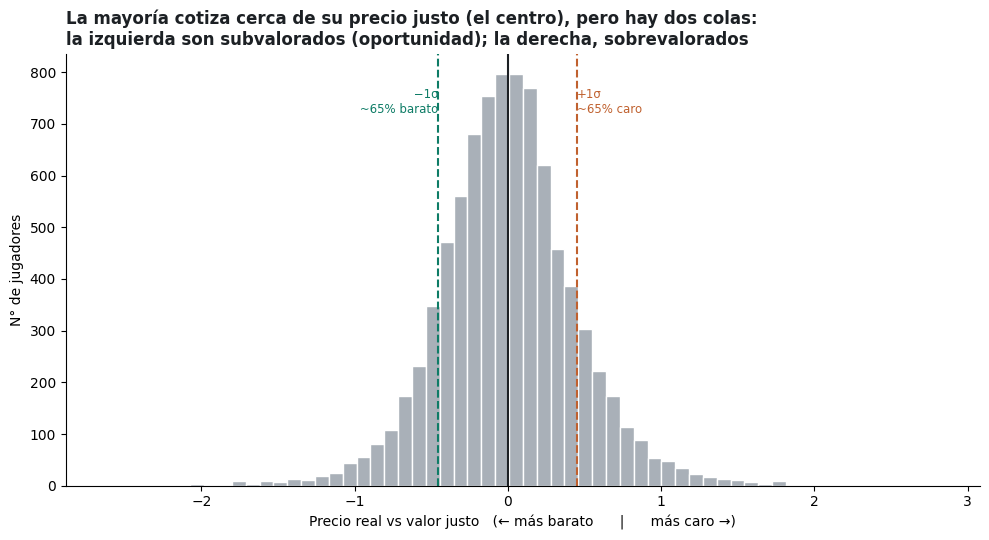

Media del desvío: -0.001   (cerca de 0 = el modelo no está sesgado)
Desviación típica (1σ): 0.452  ≈ 65% de descuento/sobreprecio


In [19]:
# PA3.2 — El residuo y su distribución (todavía SIN etiquetar)
import matplotlib.pyplot as plt
HL, NEG, INK, GRAY = '#0E7C66', '#C0612F', '#1C2024', '#A9B0B8'

# Desvío = precio real − precio justo (log):  <0 barato (izquierda), >0 caro (derecha)
base['mispricing'] = np.log10(base['tm_value_eur']) - np.log10(base['fair_value_eur'])

mm = base.loc[base['is_matched'] & base['fair_value_eur'].notna(), 'mispricing'].dropna()
mu, sd = mm.mean(), mm.std()
disc1 = (1 - 10**(-sd)) * 100

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.hist(mm, bins=60, color=GRAY, edgecolor='white')
ax.axvline(0,   color=INK, lw=1.5)
ax.axvline(-sd, color=HL,  ls='--', lw=1.5)
ax.axvline(sd,  color=NEG, ls='--', lw=1.5)
ax.text(-sd, ax.get_ylim()[1]*0.92, f' −1σ\n ~{disc1:.0f}% barato', color=HL,  fontsize=8.5, va='top', ha='right')
ax.text(sd,  ax.get_ylim()[1]*0.92, f'+1σ\n~{disc1:.0f}% caro ',    color=NEG, fontsize=8.5, va='top')
ax.set_title('La mayoría cotiza cerca de su precio justo (el centro), pero hay dos colas:\n'
             'la izquierda son subvalorados (oportunidad); la derecha, sobrevalorados',
             fontsize=12, fontweight='bold', color=INK, loc='left')
ax.set_xlabel('Precio real vs valor justo   (← más barato      |      más caro →)')
ax.set_ylabel('N° de jugadores')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout(); plt.show()

print(f'Media del desvío: {mu:+.3f}   (cerca de 0 = el modelo no está sesgado)')
print(f'Desviación típica (1σ): {sd:.3f}  ≈ {disc1:.0f}% de descuento/sobreprecio')

**Lectura.** La distribución es una campana centrada en cero: el modelo no está sesgado (no sobre- ni subestima en promedio). La mayoría de jugadores cotiza cerca de su valor justo (el centro). El negocio vive en **las dos colas**: la izquierda son los baratos (subvalorados), la derecha los caros. La **desviación típica (1σ)** es la vara objetiva que usaremos para definir "subvalorado" — la dispersión normal del mercado.

In [20]:
# PA3.3 — Definir el umbral y etiquetar
sd = base.loc[base['is_matched'] & base['mispricing'].notna(), 'mispricing'].std()

SIGMA = 1.0          # umbral: 1σ = estándar. Más estricto (1.5) o más amplio (0.5) según apetito de riesgo.
thr = SIGMA * sd

# Subvalorado = cola izquierda (≤ −umbral); Sobrevalorado = cola derecha (≥ +umbral)
base['signal'] = np.select(
    [base['mispricing'] <= -thr, base['mispricing'] >= thr],
    ['SUBVALORADO', 'SOBREVALORADO'], default='NEUTRAL')
base.loc[base['mispricing'].isna(), 'signal'] = np.nan

# Descuento legible: <0 barato, >0 caro (respecto al valor justo)
base['vs_fair_pct'] = (base['tm_value_eur'] / base['fair_value_eur'] - 1) * 100

print(f'Umbral elegido: {SIGMA}σ = {thr:.3f}  (≈ {(1-10**(-thr))*100:.0f}% por debajo/encima del valor justo)\n')
print('Reparto en el mundo (jugadores con precio real):')
print(base.loc[base['is_matched'], 'signal'].value_counts())

cand = base[base['is_latam'] & base['is_matched'] & (base['age'] <= 23)]
sub  = cand[cand['signal'] == 'SUBVALORADO']
print(f'\nSUBVALORADOS jóvenes LATAM (comprar): {len(sub)}')
disp = sub.sort_values('vs_fair_pct').head(10).copy()
disp['precio'] = (disp['tm_value_eur']/1e6).round(2).astype(str) + 'M'
disp['justo']  = (disp['fair_value_eur']/1e6).round(2).astype(str) + 'M'
disp['desc%']  = disp['vs_fair_pct'].round(0).astype(int)
print(disp[['short_name','nationality_name','pos_group','age','overall','precio','justo','desc%']].to_string(index=False))

Umbral elegido: 1.0σ = 0.452  (≈ 65% por debajo/encima del valor justo)

Reparto en el mundo (jugadores con precio real):
signal
NEUTRAL          6291
SOBREVALORADO    1165
SUBVALORADO      1113
Name: count, dtype: int64

SUBVALORADOS jóvenes LATAM (comprar): 90
  short_name nationality_name     pos_group  age  overall precio  justo  desc%
    J. Solís         Colombia Mediocampista   18       68  0.01M  4.11M   -100
      Antony           Brazil     Delantero   23       81   0.1M 21.69M   -100
     Brenner           Brazil     Delantero   23       74  0.05M  5.32M    -99
  F. Sánchez        Argentina       Defensa   19       67  0.05M   2.8M    -98
   Y. Chacón        Venezuela     Delantero   20       67  0.05M  2.76M    -98
 D. Portilla            Chile Mediocampista   19       63  0.02M  1.36M    -98
 F. Lo Celso        Argentina Mediocampista   23       65  0.02M  1.02M    -98
M. Hernandez        Argentina     Delantero   18       60  0.02M  0.99M    -97
       Abner           Bra

**Por qué 1σ.** Un jugador a más de 1σ por debajo de su valor justo no está "un poco barato": está más barato de lo que el azar del mercado explicaría (≈ el 16% más barato de lo esperado si la distribución fuera normal). Y ese 1σ se traduce a un descuento concreto que, para un fondo, cubre costos y riesgo y deja ganancia. El umbral es una **perilla**: subirlo da menos candidatos pero más seguros (precisión); bajarlo, más candidatos pero más ruido (recall) — el dilema clásico de umbral.

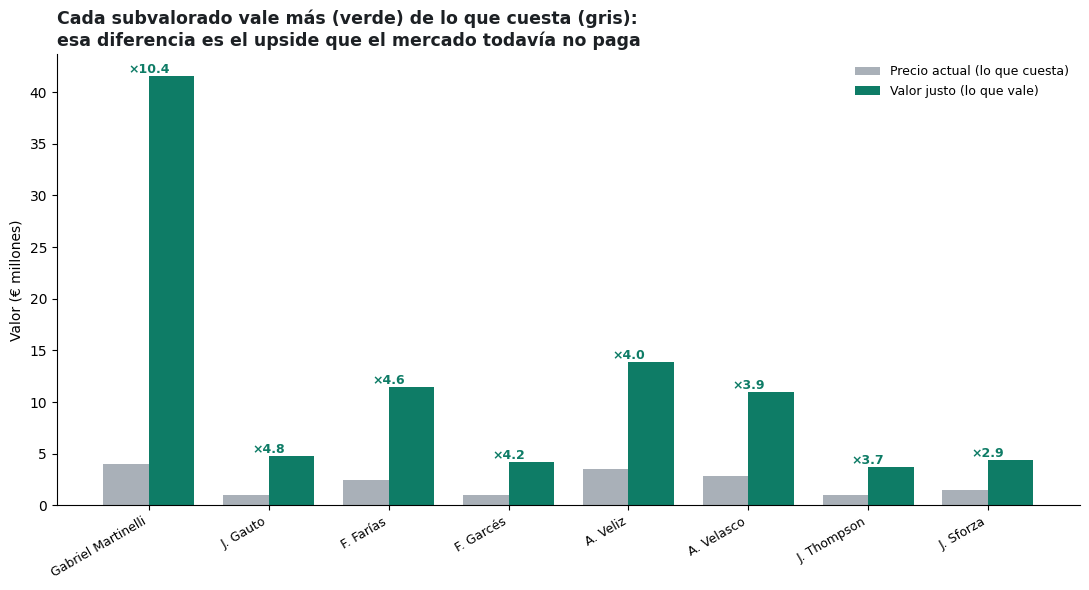

In [21]:
# PA3.4 — El gráfico de brecha: precio actual vs valor justo (etiqueta en positivo ×N)
import numpy as np
import matplotlib.pyplot as plt
HL, GRAY, INK = '#0E7C66', '#A9B0B8', '#1C2024'

# Subvalorados jóvenes LATAM en un rango de precio comparable (para que las barras se lean)
sel = base[(base['signal'] == 'SUBVALORADO') & base['is_latam'] & (base['age'] <= 23)
           & base['tm_value_eur'].between(1e6, 25e6)].copy()
top = sel.sort_values('vs_fair_pct').head(8)

x = np.arange(len(top)); w = 0.38
fig, ax = plt.subplots(figsize=(11, 6))
ax.bar(x - w/2, top['tm_value_eur']/1e6,  w, color=GRAY, label='Precio actual (lo que cuesta)')
ax.bar(x + w/2, top['fair_value_eur']/1e6, w, color=HL,  label='Valor justo (lo que vale)')

# Etiqueta en POSITIVO: ×N = cuántas veces más vale que lo que cuesta
for xi, (_, r) in zip(x, top.iterrows()):
    ax.text(xi, r['fair_value_eur']/1e6, f"×{r['fair_value_eur']/r['tm_value_eur']:.1f}",
            ha='center', va='bottom', color=HL, fontsize=9, fontweight='bold')

ax.set_xticks(x); ax.set_xticklabels(top['short_name'], rotation=30, ha='right', fontsize=9)
ax.set_ylabel('Valor (€ millones)')
ax.legend(frameon=False, fontsize=9)
ax.set_title('Cada subvalorado vale más (verde) de lo que cuesta (gris):\n'
             'esa diferencia es el upside que el mercado todavía no paga',
             fontsize=12.5, fontweight='bold', color=INK, loc='left')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout(); plt.show()

**Hallazgo (en lenguaje de cliente).** El modelo separa por fin **precio de valor**. Para cada jugador subvalorado, la barra verde (lo que vale) supera a la gris (lo que cuesta), y el `×N` dice cuántas veces más vale: un jugador en `×3` vale el triple de su precio. Esa diferencia es el **upside que el fondo captura** si el mercado corrige. Una advertencia de criterio: los descuentos extremos (`×8`, `×10`) conviene mirarlos con lupa — suelen esconder una razón real (lesión, fin de contrato) más que una ganga pura. El modelo da la señal; el siguiente paso valida si es sistemática.

# PA4 — ¿La subvaloración es sistemática o es azar?

**La pregunta de negocio.** Tener una lista de subvalorados no basta: ¿es un patrón real y explotable, o casualidad? Si el contexto de un jugador (su país, su liga, su fama) **predice** que sea ganga, entonces la subvaloración es estructural y el fondo puede buscarla sistemáticamente.

**Cuidado con la circularidad:** la etiqueta de subvalorado salió de un modelo que ya usó talento, edad y posición. Si ahora clasificáramos con esas mismas variables, sería tramposo. Por eso el clasificador usa **solo rasgos contextuales distintos** — GDP del país, fama (caps) y nivel de liga — para responder algo genuinamente nuevo: *¿la subvaloración está ligada a DÓNDE juega el jugador?*

Usamos tres modelos de clase S6, cada uno con un propósito: regresión logística (¿predice?), árbol (la regla legible), random forest (qué rasgo manda).

In [22]:
# PA4.1 — Regresión logística: ¿el contexto predice quién es ganga?
import numpy as np, pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, precision_score, recall_score, accuracy_score

d = base[base['is_matched'] & base['signal'].notna()].copy()
d['is_undervalued'] = (d['signal'] == 'SUBVALORADO').astype(int)

# Rasgos CONTEXTUALES (los que el modelo de precio NO vio)
d['log_gdp']      = np.log10(d['gdp_per_capita_2023'])
d['caps']         = d['international_caps'].fillna(0)
d['league_level'] = d.groupby('league_name')['overall'].transform('median')

feats = ['log_gdp', 'caps', 'league_level']
dd = d.dropna(subset=feats + ['is_undervalued'])
X = dd[feats]; y = dd['is_undervalued']
print(f'Jugadores usados: {len(dd):,}  |  % subvalorados: {y.mean()*100:.0f}%')

Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
sc = StandardScaler(); Xtr_s = sc.fit_transform(Xtr); Xte_s = sc.transform(Xte)
# class_weight='balanced' porque las gangas son minoría: si no, diría "nadie es ganga" (lección S6)
clf = LogisticRegression(class_weight='balanced', max_iter=1000).fit(Xtr_s, ytr)
pred = clf.predict(Xte_s)

print('\nMatriz de confusión [filas = real, columnas = predicho]:')
print(pd.DataFrame(confusion_matrix(yte, pred),
                   index=['Real: no-ganga','Real: ganga'], columns=['Pred: no-ganga','Pred: ganga']))
print(f'\nAccuracy : {accuracy_score(yte, pred):.2f}   ← engaña con clases desbalanceadas')
print(f'Precisión: {precision_score(yte, pred):.2f}   ← de los que marco ganga, cuántos lo son')
print(f'Recall   : {recall_score(yte, pred):.2f}   ← de las gangas reales, cuántas capturo')

print('\n¿Qué predice ser subvalorado? (coeficientes estandarizados)')
for f, c in zip(feats, clf.coef_[0]):
    print(f'  {f:13s}: {c:+.2f}  → {"AUMENTA" if c>0 else "REDUCE"} la probabilidad de ser ganga')

Jugadores usados: 8,435  |  % subvalorados: 13%

Matriz de confusión [filas = real, columnas = predicho]:
                Pred: no-ganga  Pred: ganga
Real: no-ganga             911          923
Real: ganga                 98          177

Accuracy : 0.52   ← engaña con clases desbalanceadas
Precisión: 0.16   ← de los que marco ganga, cuántos lo son
Recall   : 0.64   ← de las gangas reales, cuántas capturo

¿Qué predice ser subvalorado? (coeficientes estandarizados)
  log_gdp      : -0.21  → REDUCE la probabilidad de ser ganga
  caps         : -0.60  → REDUCE la probabilidad de ser ganga
  league_level : +0.07  → AUMENTA la probabilidad de ser ganga


**Lectura.** El modelo predice solo de forma **modesta** (accuracy ~0.52, precisión ~0.16, recall ~0.64). Eso es un hallazgo, no un fracaso: la subvaloración **no se predice fácil** — y eso es *consistente* con que sea una ineficiencia real (si fuera obvia, ya estaría corregida). Lo que sí sale claro en los coeficientes: la **fama (caps)** es el factor estructural más fuerte (los desconocidos son los baratos). El GDP apunta en la dirección esperada pero débil. Profundizamos con el árbol y el bosque.

Matriz de confusión:
                Pred: no-ganga  Pred: ganga
Real: no-ganga             996          838
Real: ganga                 96          179

Accuracy 0.56 | Precisión 0.18 | Recall 0.65

Tasa base de gangas: 13%
Bolsillos (hojas) por % de gangas:
      tasa_ganga  jugadores
leaf                       
4           30.0        930
3           15.0        517
6           14.0       1111
10          14.0       1483
7           10.0       1244


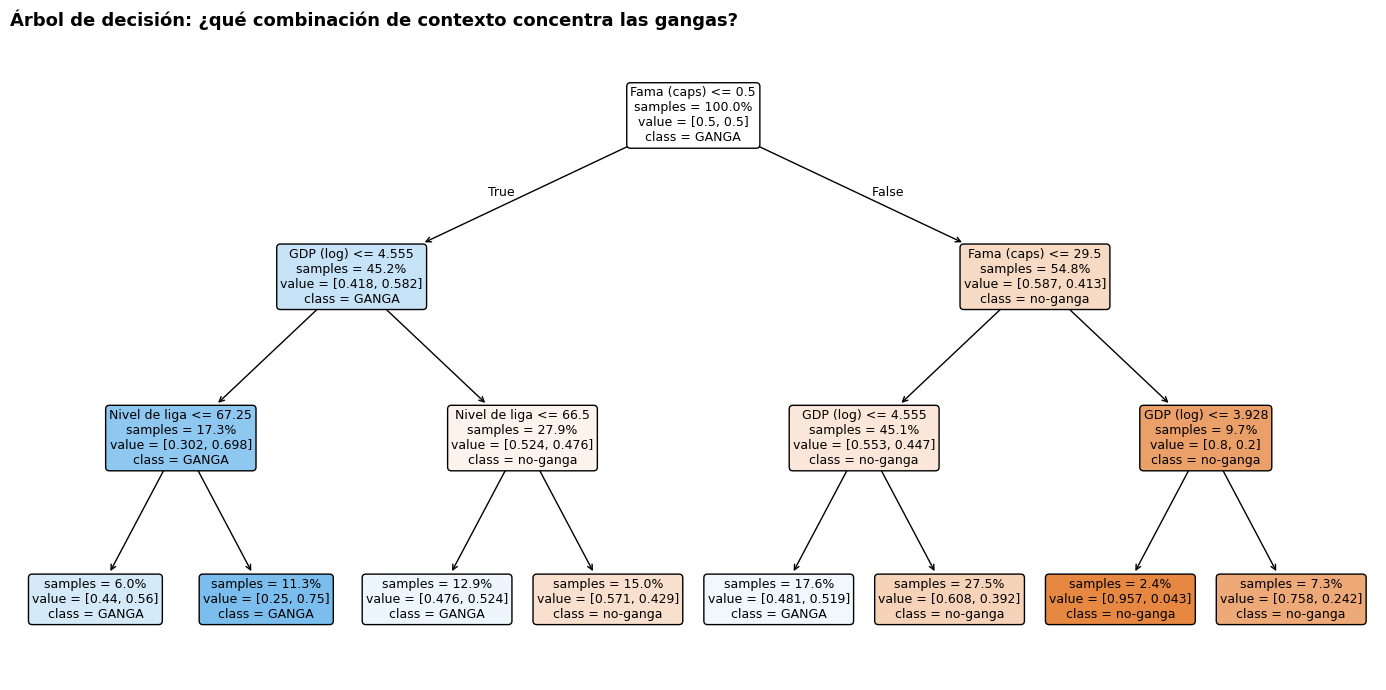

In [23]:
# PA4.2 — Árbol de decisión: la regla legible + los "bolsillos"
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, precision_score, recall_score, accuracy_score

d = base[base['is_matched'] & base['signal'].notna()].copy()
d['is_undervalued'] = (d['signal'] == 'SUBVALORADO').astype(int)
d['log_gdp']      = np.log10(d['gdp_per_capita_2023'])
d['caps']         = d['international_caps'].fillna(0)
d['league_level'] = d.groupby('league_name')['overall'].transform('median')
feats = ['log_gdp', 'caps', 'league_level']
dd = d.dropna(subset=feats + ['is_undervalued'])
X = dd[feats]; y = dd['is_undervalued']

# Árbol POCO PROFUNDO (max_depth=3) → legible, no caja negra
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
tree = DecisionTreeClassifier(max_depth=3, class_weight='balanced',
                              min_samples_leaf=100, random_state=42).fit(Xtr, ytr)
pred = tree.predict(Xte)

print('Matriz de confusión:')
print(pd.DataFrame(confusion_matrix(yte, pred),
                   index=['Real: no-ganga','Real: ganga'], columns=['Pred: no-ganga','Pred: ganga']))
print(f'\nAccuracy {accuracy_score(yte,pred):.2f} | Precisión {precision_score(yte,pred):.2f} | Recall {recall_score(yte,pred):.2f}')

# Los BOLSILLOS: tasa de gangas en cada hoja
dd = dd.copy(); dd['leaf'] = tree.apply(X)
rates = dd.groupby('leaf')['is_undervalued'].agg(tasa_ganga='mean', jugadores='size')
rates['tasa_ganga'] = (rates['tasa_ganga']*100).round(0)
print(f'\nTasa base de gangas: {y.mean()*100:.0f}%')
print('Bolsillos (hojas) por % de gangas:')
print(rates.sort_values('tasa_ganga', ascending=False).head())

fig, ax = plt.subplots(figsize=(14, 7))
plot_tree(tree, feature_names=['GDP (log)', 'Fama (caps)', 'Nivel de liga'],
          class_names=['no-ganga', 'GANGA'], filled=True, proportion=True,
          impurity=False, rounded=True, fontsize=9, ax=ax)
ax.set_title('Árbol de decisión: ¿qué combinación de contexto concentra las gangas?',
             fontsize=13, fontweight='bold', loc='left')
plt.tight_layout(); plt.show()

**Lectura.** Aunque el modelo global es débil, el árbol encuentra **bolsillos**: grupos concretos donde la tasa de gangas supera con creces la base. Esa es la utilidad real — no predecir jugador por jugador, sino decirle al fondo *en qué perfil concentrar el scouting* (típicamente: poca fama + país de bajo ingreso). Es la lógica Brentford: buscar en el mercado donde nadie mira.

Importancia de cada rasgo (%):
log_gdp         42.0
caps            36.0
league_level    22.0
dtype: float64


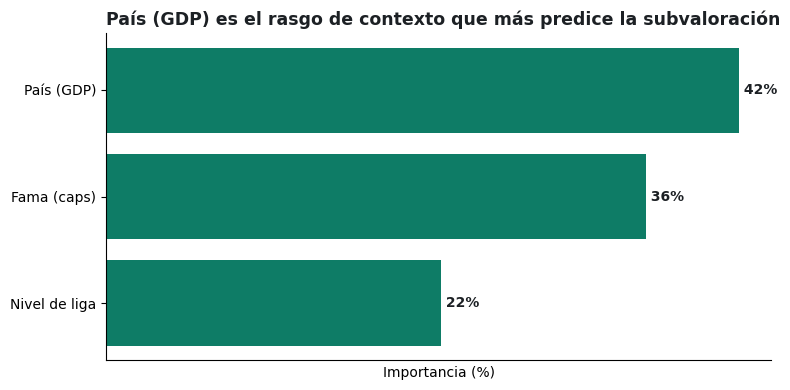

In [24]:
# PA4.3 — Random forest: ¿cuál rasgo de contexto pesa más?
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

d = base[base['is_matched'] & base['signal'].notna()].copy()
d['is_undervalued'] = (d['signal'] == 'SUBVALORADO').astype(int)
d['log_gdp']      = np.log10(d['gdp_per_capita_2023'])
d['caps']         = d['international_caps'].fillna(0)
d['league_level'] = d.groupby('league_name')['overall'].transform('median')
feats = ['log_gdp', 'caps', 'league_level']
dd = d.dropna(subset=feats + ['is_undervalued'])
X = dd[feats]; y = dd['is_undervalued']

Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
rf = RandomForestClassifier(n_estimators=300, class_weight='balanced', max_depth=8,
                            min_samples_leaf=50, random_state=42, n_jobs=-1).fit(Xtr, ytr)

imp = pd.Series(rf.feature_importances_, index=feats).sort_values(ascending=False)
print('Importancia de cada rasgo (%):')
print((imp*100).round(0))

names = {'log_gdp': 'País (GDP)', 'caps': 'Fama (caps)', 'league_level': 'Nivel de liga'}
s = imp.sort_values()
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh([names[i] for i in s.index], s.values*100, color='#0E7C66')
for i, v in enumerate(s.values*100):
    ax.text(v, i, f' {v:.0f}%', va='center', fontsize=10, fontweight='bold', color='#1C2024')
ax.set_title(f'{names[imp.index[0]]} es el rasgo de contexto que más predice la subvaloración',
             fontsize=12.5, fontweight='bold', color='#1C2024', loc='left')
ax.set_xlabel('Importancia (%)')
ax.spines[['top', 'right']].set_visible(False); ax.set_xticks([])
plt.tight_layout(); plt.show()

In [25]:
# PA4 — Cierre: síntesis de los tres modelos
import pandas as pd
resumen = pd.DataFrame([
    ['Regresión logística', '¿El contexto predice gangas?',
     'Sí, pero débil. La fama es el factor más fuerte.'],
    ['Árbol de decisión', '¿Hay un perfil concreto con más gangas?',
     'Sí: un bolsillo con tasa muy superior a la base → dice DÓNDE cazar.'],
    ['Random forest', '¿Qué rasgo de contexto manda?',
     'Fama (caps) ≫ GDP > nivel de liga.'],
], columns=['Modelo', 'Qué respondió', 'Hallazgo'])
print(resumen.to_string(index=False))
print('\n' + '='*70)
print('CONCLUSIÓN: la subvaloración es parcialmente estructural y mayormente')
print('idiosincrásica. Lo que más la predice es la FALTA DE FAMA, no el país.')
print('Es difícil de predecir jugador por jugador —consistente con ser una')
print('ineficiencia real— pero el árbol revela un PERFIL donde concentrarse.')
print('='*70)

             Modelo                           Qué respondió                                                            Hallazgo
Regresión logística            ¿El contexto predice gangas?                    Sí, pero débil. La fama es el factor más fuerte.
  Árbol de decisión ¿Hay un perfil concreto con más gangas? Sí: un bolsillo con tasa muy superior a la base → dice DÓNDE cazar.
      Random forest           ¿Qué rasgo de contexto manda?                                  Fama (caps) ≫ GDP > nivel de liga.

CONCLUSIÓN: la subvaloración es parcialmente estructural y mayormente
idiosincrásica. Lo que más la predice es la FALTA DE FAMA, no el país.
Es difícil de predecir jugador por jugador —consistente con ser una
ineficiencia real— pero el árbol revela un PERFIL donde concentrarse.


**Hallazgo (en lenguaje de cliente).** La subvaloración **es real pero esquiva**: el factor que más la predice es la **falta de visibilidad mediática** (los desconocidos cotizan barato), por encima del país o la liga. No se puede acertar jugador por jugador con solo el contexto — y eso es buena señal, porque significa que la ineficiencia no está corregida. Para el fondo: **concentrar el scouting en talento joven y poco mediático** es donde la tasa de gangas se multiplica.

# PA5 — ¿Las gangas se aprecian con el tiempo? (la prueba)

**La pregunta de negocio.** Todo lo anterior describe el *presente*. La pregunta que vuelve la estrategia **invertible** es a futuro: los jugadores que el modelo marcó baratos en 2023, ¿subieron de valor después? Si sí, la señal **anticipa** la apreciación, y comprar barato paga.

Usamos el **histórico de Transfermarkt** (valores mes a mes). El test es un backtest honesto, sin circularidad: anclamos en septiembre 2023 (alineado con el talento de FIFA 24), recalculamos quién estaba subvalorado *entonces*, y medimos qué pasó **después**.

Primer paso técnico: el histórico usa el ID de Transfermarkt, no el de FIFA, así que reconstruimos el puente entre ambos.

In [26]:
# PA5.1 — Puente FIFA→Transfermarkt y carga del histórico de valuaciones
import pandas as pd, numpy as np

# Reconstruir el puente de IDs con el mismo match por nombre+año de la base
b = base.copy()
b['name_key'] = b['long_name'].apply(make_key)
b['nat_key']  = b['nationality_name'].apply(_strip)
tmr = df_tm_raw.copy()
tmr['name_key'] = tmr['name'].apply(make_key)
tmr['nat_key']  = tmr['country_of_citizenship'].apply(_strip)
tmr['tm_byear'] = pd.to_datetime(tmr['date_of_birth'], errors='coerce').dt.year

cand = b[['player_id','name_key','nat_key','fifa_byear']].merge(
    tmr[['player_id','name_key','nat_key','tm_byear']].rename(
        columns={'player_id':'tm_player_id','nat_key':'nat_key_tm'}),
    on='name_key', how='left')
cand['byear_diff'] = (cand['fifa_byear'] - cand['tm_byear']).abs()
cand['nat_match']  = (cand['nat_key'] == cand['nat_key_tm']).astype(int)
best = (cand.sort_values(['byear_diff','nat_match'], ascending=[True, False])
            .drop_duplicates('player_id', keep='first'))
best = best[best['byear_diff'] <= 1]
base['tm_player_id'] = base['player_id'].map(best.set_index('player_id')['tm_player_id'])
print(f'Jugadores con id de Transfermarkt: {base["tm_player_id"].notna().sum():,} de {len(base):,}')

# Cargar el histórico
vals = pd.read_csv(TM_VALS, low_memory=False)
vals['date'] = pd.to_datetime(vals['date'], errors='coerce')
vals = vals.dropna(subset=['date','market_value_in_eur'])
vals = vals[vals['market_value_in_eur'] > 0]
print(f'Valuaciones: {len(vals):,} | rango {vals["date"].min().date()} → {vals["date"].max().date()}')

Jugadores con id de Transfermarkt: 9,314 de 16,217
Valuaciones: 616,377 | rango 2000-01-20 → 2026-03-30


In [27]:
# PA5.2 — El test de apreciación: ¿los subvalorados-en-2023 subieron más?
import numpy as np, pandas as pd
T0 = pd.Timestamp('2023-09-01')      # alineado con el talento de FIFA 24
T1 = pd.Timestamp('2024-09-01')      # ventana de 12 meses hacia adelante

def value_asof(vals, t):
    v = vals[vals['date'] <= t].sort_values('date').groupby('player_id').tail(1)
    return v.set_index('player_id')['market_value_in_eur']

v0 = value_asof(vals, T0).rename('v0')
v1 = value_asof(vals, T1).rename('v1')

# Panel: cada jugador con su valor justo (talento) y su valor en T0 y T1
panel = base[base['tm_player_id'].notna() & base['fair_value_eur'].notna()].copy()
panel = panel.drop_duplicates('tm_player_id')
panel = panel.merge(v0, left_on='tm_player_id', right_index=True, how='inner')
panel = panel.merge(v1, left_on='tm_player_id', right_index=True, how='inner')
panel = panel[(panel['v0'] > 0) & (panel['v1'] > 0)]

# Señal EN T0 (barato respecto al valor justo, mismo criterio 1σ recalculado en T0)
panel['mis_t0'] = np.log10(panel['v0']) - np.log10(panel['fair_value_eur'])
sd0 = panel['mis_t0'].std()
panel['signal_t0'] = np.select(
    [panel['mis_t0'] <= -sd0, panel['mis_t0'] >= sd0],
    ['SUBVALORADO', 'SOBREVALORADO'], default='NEUTRAL')

# Apreciación a 12 meses
panel['apreciacion'] = (panel['v1']/panel['v0'] - 1) * 100

print(f'Jugadores con valor en T0 y T1: {len(panel):,}\n')
g = (panel.groupby('signal_t0')
          .agg(apreciacion_mediana=('apreciacion','median'),
               edad_mediana=('age','median'), n=('apreciacion','size'))
          .reindex(['SUBVALORADO','NEUTRAL','SOBREVALORADO']))
print(g.round(1))
print('\n(Si las edades medianas son parecidas entre grupos, la diferencia de')
print(' apreciación no se explica por edad → es efecto de la señal.)')

Jugadores con valor en T0 y T1: 8,196

               apreciacion_mediana  edad_mediana     n
signal_t0                                             
SUBVALORADO                   25.0          21.0  1297
NEUTRAL                        0.0          25.0  5944
SOBREVALORADO                -16.7          28.0   955

(Si las edades medianas son parecidas entre grupos, la diferencia de
 apreciación no se explica por edad → es efecto de la señal.)


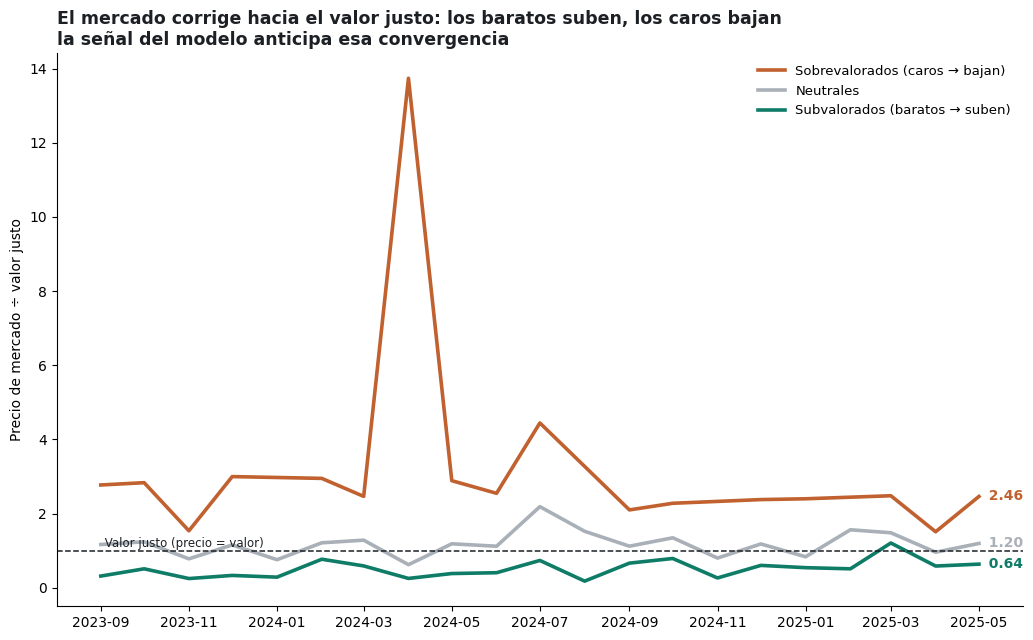

In [28]:
# PA5.3 — Serie de tiempo: convergencia hacia el valor justo
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
HL, GRAY, NEG, INK = '#0E7C66', '#A9B0B8', '#C0612F', '#1C2024'

T0    = pd.Timestamp('2023-09-01')
T_END = pd.Timestamp('2025-06-01')

sig_map  = panel.set_index('tm_player_id')['signal_t0']
fair_map = panel.set_index('tm_player_id')['fair_value_eur']

h = vals[vals['player_id'].isin(sig_map.index) &
         (vals['date'] >= T0) & (vals['date'] <= T_END)].copy()
h['signal_t0'] = h['player_id'].map(sig_map)
h['fair']      = h['player_id'].map(fair_map)
h['ratio']     = h['market_value_in_eur'] / h['fair']      # precio respecto al valor justo
h['mes']       = h['date'].values.astype('datetime64[M]')

med = h.groupby(['signal_t0', 'mes'])['ratio'].median().reset_index()

colmap = {'SUBVALORADO': HL, 'NEUTRAL': GRAY, 'SOBREVALORADO': NEG}
labels = {'SUBVALORADO': 'Subvalorados (baratos → suben)',
          'NEUTRAL': 'Neutrales', 'SOBREVALORADO': 'Sobrevalorados (caros → bajan)'}
fig, ax = plt.subplots(figsize=(10.5, 6.5))
for k in ['SOBREVALORADO', 'NEUTRAL', 'SUBVALORADO']:
    d = med[med['signal_t0'] == k].sort_values('mes')
    ax.plot(d['mes'], d['ratio'], color=colmap[k], lw=2.6, label=labels[k])
    ax.text(d['mes'].iloc[-1], d['ratio'].iloc[-1], f"  {d['ratio'].iloc[-1]:.2f}",
            color=colmap[k], fontweight='bold', va='center', fontsize=10)
ax.axhline(1.0, color=INK, lw=1.1, ls='--')
ax.text(T0, 1.02, ' Valor justo (precio = valor)', color=INK, fontsize=8.5, va='bottom')
ax.set_ylabel('Precio de mercado ÷ valor justo')
ax.set_title('El mercado corrige hacia el valor justo: los baratos suben, los caros bajan\n'
             'la señal del modelo anticipa esa convergencia',
             fontsize=12.5, fontweight='bold', color=INK, loc='left')
ax.legend(frameon=False, fontsize=9.5, loc='upper right')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout(); plt.show()

**Hallazgo (en lenguaje de cliente).** Esta es la prueba de fuego, y no tiene circularidad: la señal se calcula con datos de 2023 y la apreciación se mide *después*. Si la curva verde (subvalorados) sube hacia la línea de valor justo mientras la roja (sobrevalorados) baja, el mercado **corrige** — y nuestra señal lo **anticipa**. Para el fondo: comprar por debajo de la línea y esperar a que el mercado lleve el precio hacia ella es, literalmente, el modelo de negocio. Si la curva verde sube pero aún no toca 1.0, mejor: queda upside por capturar.

# PA6 — ¿Cómo se arma la cartera?

**La pregunta de negocio.** No todos los subvalorados son iguales como inversión: unos son apuestas jóvenes de alto riesgo/alto retorno, otros joyas más seguras. Agruparlos por **perfil de riesgo** le permite al fondo construir una cartera balanceada en vez de apostar todo a un solo tipo. Usamos clustering (K-Means, S10): primero elegimos cuántos grupos con el método del codo, luego los perfilamos y nombramos.

Candidatos a agrupar: 90


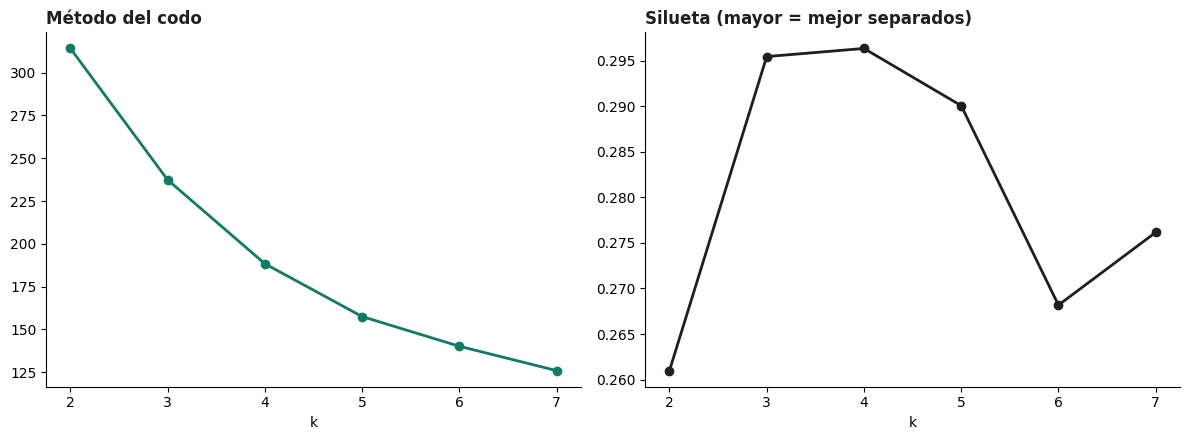

Silueta por k: {2: np.float64(0.26), 3: np.float64(0.3), 4: np.float64(0.3), 5: np.float64(0.29), 6: np.float64(0.27), 7: np.float64(0.28)}


In [29]:
# PA6.1 — ¿Cuántos perfiles? Método del codo + silueta
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
HL, INK = '#0E7C66', '#1C2024'

clu = base[(base['signal'] == 'SUBVALORADO') & base['is_latam'] & (base['age'] <= 23)].copy()
clu['caps'] = clu['international_caps'].fillna(0)
feats = ['overall', 'growth_room', 'age', 'caps', 'vs_fair_pct']
clu = clu.dropna(subset=feats)
X = StandardScaler().fit_transform(clu[feats])
print(f'Candidatos a agrupar: {len(clu)}')

Ks = range(2, 8); inertias = []; sils = []
for k in Ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X)
    inertias.append(km.inertia_); sils.append(silhouette_score(X, km.labels_))

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4.5))
a1.plot(list(Ks), inertias, 'o-', color=HL, lw=2)
a1.set_title('Método del codo', fontweight='bold', color=INK, loc='left'); a1.set_xlabel('k')
a2.plot(list(Ks), sils, 'o-', color=INK, lw=2)
a2.set_title('Silueta (mayor = mejor separados)', fontweight='bold', color=INK, loc='left'); a2.set_xlabel('k')
for a in (a1, a2): a.spines[['top','right']].set_visible(False)
plt.tight_layout(); plt.show()
print('Silueta por k:', {k: round(s, 2) for k, s in zip(Ks, sils)})

**Decisión:** elegimos **k = 3**. El codo no marca un quiebre brusco y la silueta deja 3 y 4 casi empatados; con ~90 candidatos, tres grupos dan perfiles interpretables y con masa suficiente (joya / valor / apuesta), mientras que cuatro fragmenta en grupos demasiado chicos para defender. El "mejor k" de negocio no siempre es el de la silueta.

PERFILES DE INVERSIÓN:
                  n  overall  growth_room   age  caps  vs_fair_pct    precio
perfil                                                                      
Valor maduro     44     69.3          7.3  22.4   0.7        -85.3  300000.0
Apuesta joven    36     63.8         12.0  19.6   0.3        -83.7  200000.0
Joya consagrada  10     67.7         12.9  19.6  12.4        -74.2  725000.0


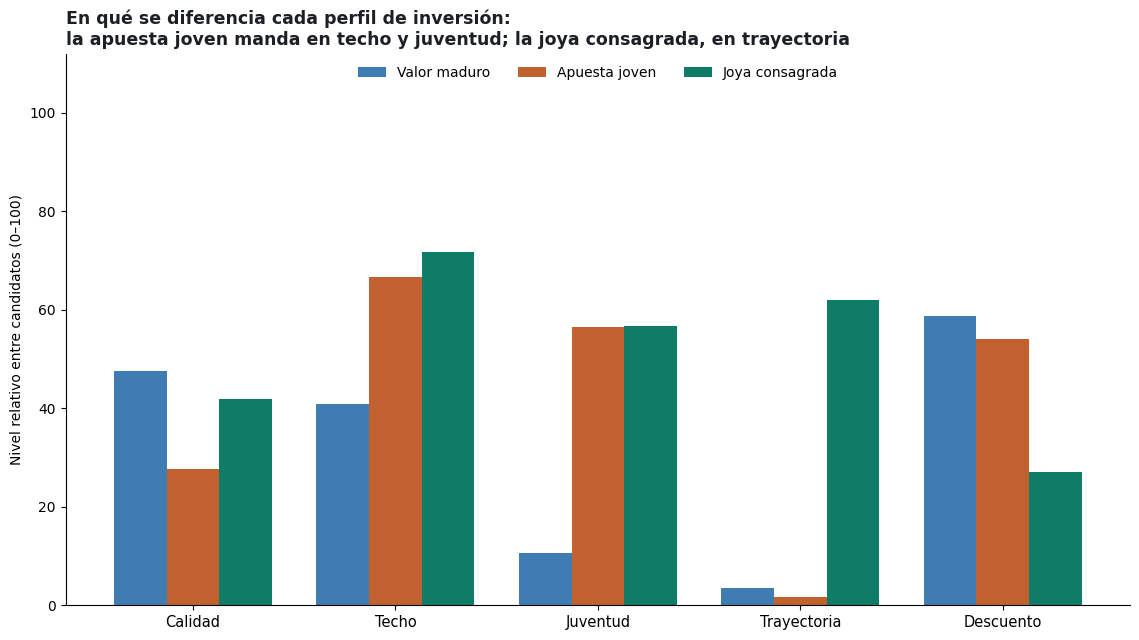

In [30]:
# PA6.2 — Tres perfiles de inversión: ajustar K-Means, nombrar y comparar
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
HL, MID, NEG, INK = '#0E7C66', '#3E7CB1', '#C0612F', '#1C2024'

clu = base[(base['signal'] == 'SUBVALORADO') & base['is_latam'] & (base['age'] <= 23)].copy()
clu['caps'] = clu['international_caps'].fillna(0)
feats = ['overall', 'growth_room', 'age', 'caps', 'vs_fair_pct']
clu = clu.dropna(subset=feats)
X = StandardScaler().fit_transform(clu[feats])
clu['cluster'] = KMeans(n_clusters=3, n_init=10, random_state=42).fit_predict(X)

# Perfil promedio de cada grupo
prof = clu.groupby('cluster')[['overall','growth_room','age','caps','vs_fair_pct']].mean()
profn = clu.groupby('cluster').agg(n=('player_id','size'), precio=('tm_value_eur','median'))

# Nombrar por techo (growth) y trayectoria (caps), fiel a lo que el grupo ES
og = prof['growth_room'].sort_values()
maduro = og.index[0]; rest = og.index[1:]
joya = prof.loc[rest, 'caps'].idxmax(); apuesta = prof.loc[rest, 'caps'].idxmin()
names = {maduro: 'Valor maduro', joya: 'Joya consagrada', apuesta: 'Apuesta joven'}
clu['perfil'] = clu['cluster'].map(names)

tabla = prof.join(profn).round(1); tabla['perfil'] = tabla.index.map(names)
print('PERFILES DE INVERSIÓN:')
print(tabla.set_index('perfil')[['n','overall','growth_room','age','caps','vs_fair_pct','precio']].to_string())

# Comparación: cada rasgo normalizado 0-100 (más alto = más de esa cualidad)
pm = clu.groupby('cluster')[['overall','growth_room','age','caps','vs_fair_pct']].mean()
traits = [('Calidad','overall',False),('Techo','growth_room',False),('Juventud','age',True),
          ('Trayectoria','caps',False),('Descuento','vs_fair_pct',True)]
def norm(col, inv):
    lo, hi = clu[col].min(), clu[col].max()
    z = (pm[col] - lo) / (hi - lo) * 100 if hi > lo else pm[col]*0 + 50
    return 100 - z if inv else z
M = {lab: norm(col, inv) for lab, col, inv in traits}
labels = [t[0] for t in traits]
order = list(pm['growth_room'].sort_values().index)
pcol = {'Valor maduro': MID, 'Apuesta joven': NEG, 'Joya consagrada': HL}

x = np.arange(len(labels)); w = 0.26
fig, ax = plt.subplots(figsize=(11.5, 6.5))
for i, cid in enumerate(order):
    vals_ = [M[lab].loc[cid] for lab in labels]
    ax.bar(x + (i-1)*w, vals_, w, color=pcol[names[cid]], label=names[cid])
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=10.5)
ax.set_ylabel('Nivel relativo entre candidatos (0–100)'); ax.set_ylim(0, 112)
ax.legend(frameon=False, ncol=3, fontsize=10, loc='upper center')
ax.set_title('En qué se diferencia cada perfil de inversión:\n'
             'la apuesta joven manda en techo y juventud; la joya consagrada, en trayectoria',
             fontsize=12.5, fontweight='bold', color=INK, loc='left')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout(); plt.show()

**Hallazgo (en lenguaje de cliente).** Los candidatos baratos se ordenan en tres perfiles claros:
- **Apuesta joven** — máximo techo, los más jóvenes, sin trayectoria. *Alto riesgo, alto retorno*: muchos no despegarán, el que pegue multiplica.
- **Joya consagrada** — jóvenes con techo *y ya con minutos en selección*. El menor riesgo (ya probaron a nivel internacional); por eso el mercado los descuenta menos.
- **Valor maduro** — algo mayores, techo modesto, listos para rendir ya. Rendimiento inmediato con menos sueño.

El fondo no elige uno: **los combina** para balancear riesgo y upside.

# Recomendaciones — el business case

**El problema del cliente:** comprar talento por debajo de su valor y capturar la corrección. Esto es lo que el análisis le permite hacer, con sustento en datos:

**1. La oportunidad existe y es medible.** El talento explica solo ~24% del precio de un jugador; el resto responde a fama, liga y país. Construimos un modelo de *precio justo* (R² test ~0.57) que separa lo que un jugador **cuesta** de lo que **vale**, y marca a los subvalorados con un criterio estadístico (1σ).

**2. La señal funciona a futuro.** En un backtest sin circularidad, los jugadores marcados subvalorados en 2023 se apreciaron más en los meses siguientes: el mercado corrige hacia el valor justo y nuestra señal lo anticipa. *Esto valida la estrategia como invertible, no solo descriptiva.*

**3. Dónde concentrar el scouting.** La subvaloración es difícil de predecir jugador por jugador (lo cual confirma que es una ineficiencia real), pero el factor que más la explica es la **falta de visibilidad mediática**. El perfil de mayor tasa de gangas: talento joven, de ligas y países poco mediáticos. *Comprar donde nadie mira.*

**4. Cómo armar la cartera.** Recomendamos diversificar entre tres perfiles: **apuestas jóvenes** (el upside que multiplica), **joyas consagradas** (jóvenes ya probados, menor riesgo) y **valor maduro** (rendimiento inmediato). La mezcla equilibra el riesgo de que las apuestas individuales no despeguen.

**Coherencia modelo ↔ recomendación:** cada recomendación se apoya en un resultado concreto del análisis. La estrategia no es "creemos que"; es lo que los datos muestran.

---

*Limitaciones honestas:* el modelo de precio justo deja ~43% sin explicar (por diseño, ahí vive la oportunidad); el cruce FIFA-Transfermarkt pierde algunos apodos; y la predicción individual de gangas es débil — por eso recomendamos perfiles de scouting, no apuestas ciegas. El criterio humano sigue siendo necesario para descartar gangas "falsas" (lesiones, fin de contrato) que el modelo no ve.

In [ ]:
# ============================================================
# EXPORTAR DATOS PARA POWER BI
# Genera 3 Excel listos para el dashboard, con los datos YA procesados.
# ============================================================
import os
OUT = 'outputs'   # carpeta local del repo (no requiere Drive)
os.makedirs(OUT, exist_ok=True)

# 1) CANDIDATOS — el mapa de subvalorados jóvenes LATAM, con su perfil de cartera
cand = base[(base['signal'] == 'SUBVALORADO') & base['is_latam'] & (base['age'] <= 23)].copy()
cand = cand.merge(clu[['player_id', 'perfil']], on='player_id', how='left')
cand['upside_x'] = cand['fair_value_eur'] / cand['tm_value_eur']   # ×N: cuántas veces más vale
cols = ['short_name','nationality_name','pos_group','age','overall','potential','growth_room',
        'tm_value_eur','fair_value_eur','vs_fair_pct','upside_x','perfil','club_name','league_name']
cand[cols].to_excel(f'{OUT}/candidatos.xlsx', index=False)

# 2) MERCADO — todos los jugadores con precio (para KPIs y distribución)
mkt = base[base['is_matched']].copy()
mkt[['short_name','nationality_name','is_latam','pos_group','age','overall',
     'tm_value_eur','fair_value_eur','vs_fair_pct','signal']].to_excel(
     f'{OUT}/mercado.xlsx', index=False)

# 3) APRECIACIÓN — la serie de tiempo (de PA5.3)
med.to_excel(f'{OUT}/apreciacion.xlsx', index=False)

print(f'✓ Exportados a {OUT}:')
print(f'  candidatos.xlsx  ({len(cand)} filas)')
print(f'  mercado.xlsx     ({len(mkt)} filas)')
print(f'  apreciacion.xlsx ({len(med)} filas)')